In [60]:
import torch
from matplotlib import pyplot as plt
from matplotlib.dates import MonthLocator, num2date
from matplotlib.ticker import FuncFormatter
from datetime import datetime

import pandas as pd
import io
import numpy as np
import sys

from prophet import Prophet

In [85]:
# Define constants
time_column = 'HourDK'
production_columns = ['OffshoreWindLt100MW_MWh',
       'OffshoreWindGe100MW_MWh', 'OnshoreWindLt50kW_MWh',
       'OnshoreWindGe50kW_MWh', 'HydroPowerMWh', 'SolarPowerLt10kW_MWh',
       'SolarPowerGe10Lt40kW_MWh', 'SolarPowerGe40kW_MWh',
       'SolarPowerSelfConMWh']
consumption_column = 'GrossConsumptionMWh'
renewable_production_column = 'RenewableProduction_MWh'
net_load_column = 'NetLoad_MWh'

# Future timeframe
FUTURE_YEAR = 1
one_year_timeframe = FUTURE_YEAR * 365 * 24

# New projects load
NEW_PROJECT_PRODUCTION_PER_YEAR = 1313400
# NEW_PROJECT_PRODUCTION_PER_YEAR = 109000

In [86]:
def read_excel_data(xlsx_file_path: str, skiprows=0):
    """
    Function to read the excel file using python pandas package
    """
    try:
        return pd.read_excel(xlsx_file_path, skiprows=skiprows)
    except:
        return None

In [5]:
def update_net_load(df_data: pd.DataFrame):
    # Get only DK1 data
    df_data = df_data[df_data['PriceArea'] == 'DK1']

    # Renew Production = Sum of production_columns
    df_data[renewable_production_column] = df_data[production_columns].sum(axis=1)

    # Net Load = Consumption - Renew Production
    df_data[net_load_column] = df_data[consumption_column] - df_data[renewable_production_column]

    df_data_filtered = df_data[[time_column, renewable_production_column, consumption_column, net_load_column]]
    return df_data_filtered.reset_index(drop=True) # Reset index to zero

# 1. Read the production and consumption excel data

In [92]:
energy_data_file = "E:\\Code\\Reshma\\Energy\\data\\ProductionConsumptionSettlement_Jan22_Nov25.xlsx"
energy_df = read_excel_data(energy_data_file, skiprows=0)
if energy_df is None:
    print("The data read from excel is None")
else:
    energy_df = update_net_load(energy_df)

In [93]:
energy_df

,HourDK,RenewableProduction_MWh,GrossConsumptionMWh,NetLoad_MWh
0,2022-01-01 00:00:00,2057.425672,2196.234258,138.808586
1,2022-01-01 01:00:00,2041.301143,2206.210314,164.909171
2,2022-01-01 02:00:00,1941.723910,2147.758315,206.034405
3,2022-01-01 03:00:00,1749.092176,2023.389045,274.296869
4,2022-01-01 04:00:00,1590.741475,2050.223766,459.482291
...,...,...,...,...
34315,2025-11-30 19:00:00,4631.274761,3230.522946,-1400.751815
34316,2025-11-30 20:00:00,4688.119455,3314.795507,-1373.323948
34317,2025-11-30 21:00:00,4725.786600,3296.066992,-1429.719608
34318,2025-11-30 22:00:00,4702.579993,3437.195354,-1265.384639


In [95]:
def prepare_data(df, x_col_name, y_col_name):
    """
    This function reads the data using x col name and y col name.
    The time and data column names are renamed to "ds" and "y" respectively.
    Duplicated datas are avoided. Date-time is converted to date_time class format
    """
    df[x_col_name] = pd.to_datetime(df[x_col_name])
    df = df.rename(columns={x_col_name: 'ds', y_col_name: 'y'})
    df = df.drop_duplicates(subset=["ds"], keep="first")
    df = df[["ds", "y"]]
    return df.reset_index(drop=True) # Reset index to zero

In [168]:
production_df = prepare_data(energy_df.copy(), x_col_name=time_column, y_col_name=renewable_production_column)
consumption_df = prepare_data(energy_df.copy(), x_col_name=time_column, y_col_name=consumption_column)
netload_df = prepare_data(energy_df.copy(), x_col_name=time_column, y_col_name=net_load_column)

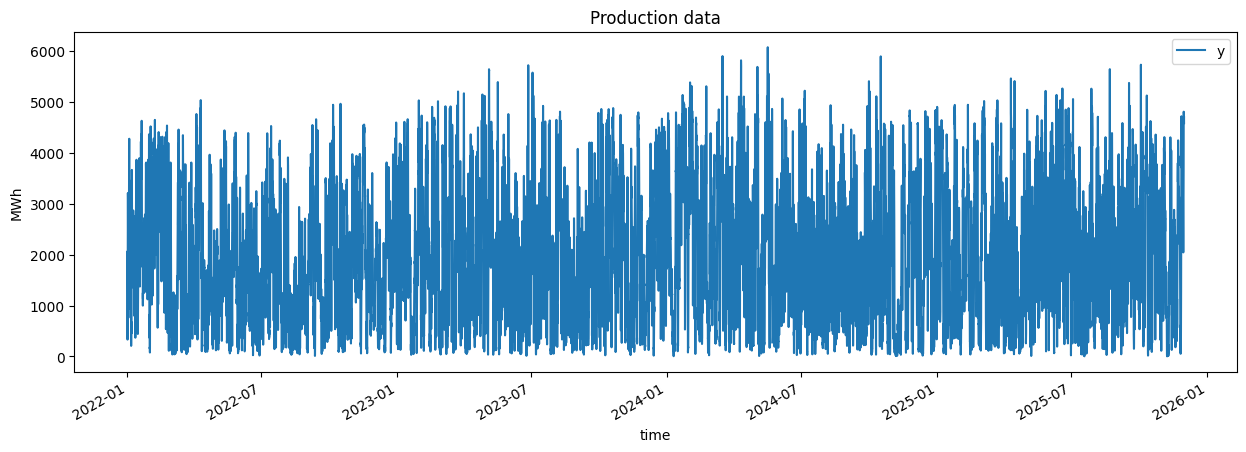

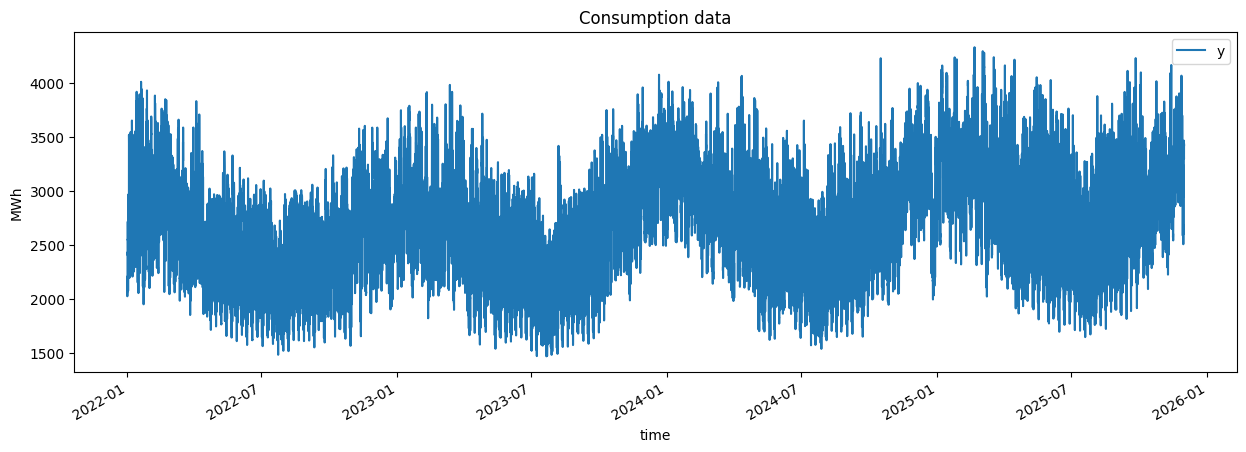

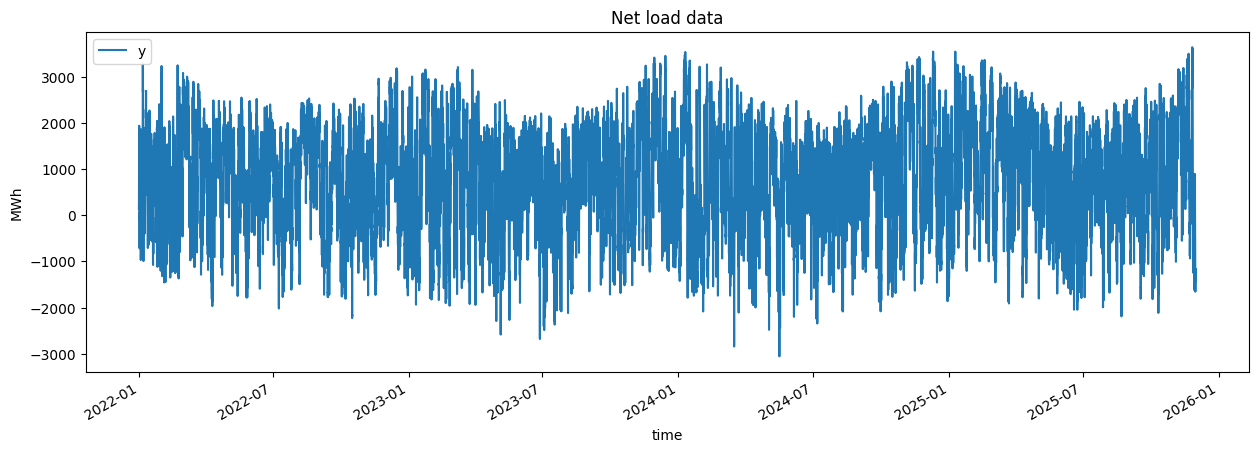

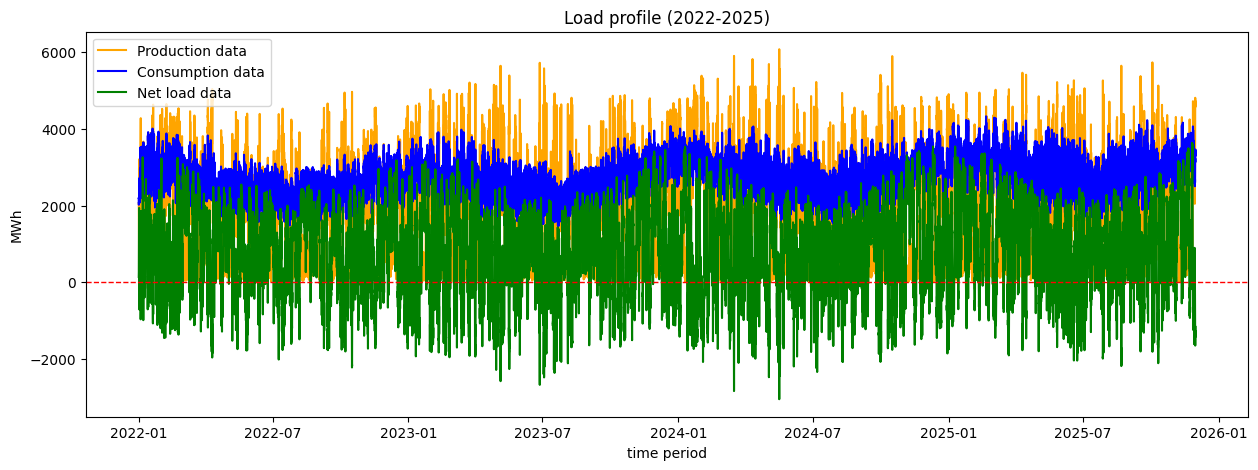

In [108]:
# Filtering only the year 2024 data. Set the variable only_2024 as True
only_2024 = False
if only_2024 is True:
    production_df = production_df[(production_df["ds"] > "2023-12-31") & (production_df["ds"] < "2025-01-01")]
    consumption_df = consumption_df[(consumption_df["ds"] > "2023-12-31") & (consumption_df["ds"] < "2025-01-01")]
    netload_df = netload_df[(netload_df["ds"] > "2023-12-31") & (netload_df["ds"] < "2025-01-01")]

# Plot the data
production_plt = production_df.plot(x="ds", y="y", figsize=(15, 5), title="Production data", xlabel="time", ylabel="MWh")
consumption_plt = consumption_df.plot(x="ds", y="y", figsize=(15, 5), title="Consumption data", xlabel="time", ylabel="MWh")
netload_plt = netload_df.plot(x="ds", y="y", figsize=(15, 5), title="Net load data", xlabel="time", ylabel="MWh")

plt.figure(figsize=(15, 5))
plt.plot(production_df["ds"], production_df["y"], label="Production data", color="orange")
plt.plot(consumption_df["ds"], consumption_df["y"], label="Consumption data", color="blue")
plt.plot(netload_df["ds"], netload_df["y"], linestyle='-', label="Net load data", color="green")
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.xlabel("time period")
plt.ylabel("MWh")
plt.title("Load profile (2022-2025)")
plt.legend()
plt.savefig("graphs\\load_2022-2025_profile_4_1.png")

## 2. Define, train and analyse the model

In this part, a model is defined using Meta's library Prophet. Daily, Weekly and Yearly seasonality is analyzed for the data. The default settings are used.

In [109]:
def run_model_prophet(df):
    """
    Define the model using Prophet library
    """
    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
    )
    model.fit(df)
    return model

In [115]:
def predict_model_prophet(model, fig_name):
    df_future = model.make_future_dataframe(periods=one_year_timeframe, freq='h')
    
    # Predict the future
    forecast = model.predict(df_future)
    
    # Visualize the forecast
    # model.plot(forecast)
    plot_com_fig = model.plot_components(forecast)
    path_name = f"graphs\\{fig_name}_4_2.png"
    plot_com_fig.savefig(path_name)
    return forecast

In [111]:
print("Building model for Production data")
production_model = run_model_prophet(production_df)

print("Building model for Consumption data")
consumption_model = run_model_prophet(consumption_df)

print("Building model for Net load data")
netload_model = run_model_prophet(netload_df)

Building model for Production data


17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:05:07 - cmdstanpy - INFO - Chain [1] done processing


Building model for Consumption data


17:05:17 - cmdstanpy - INFO - Chain [1] start processing
17:05:50 - cmdstanpy - INFO - Chain [1] done processing


Building model for Net load data


17:05:58 - cmdstanpy - INFO - Chain [1] start processing
17:06:08 - cmdstanpy - INFO - Chain [1] done processing


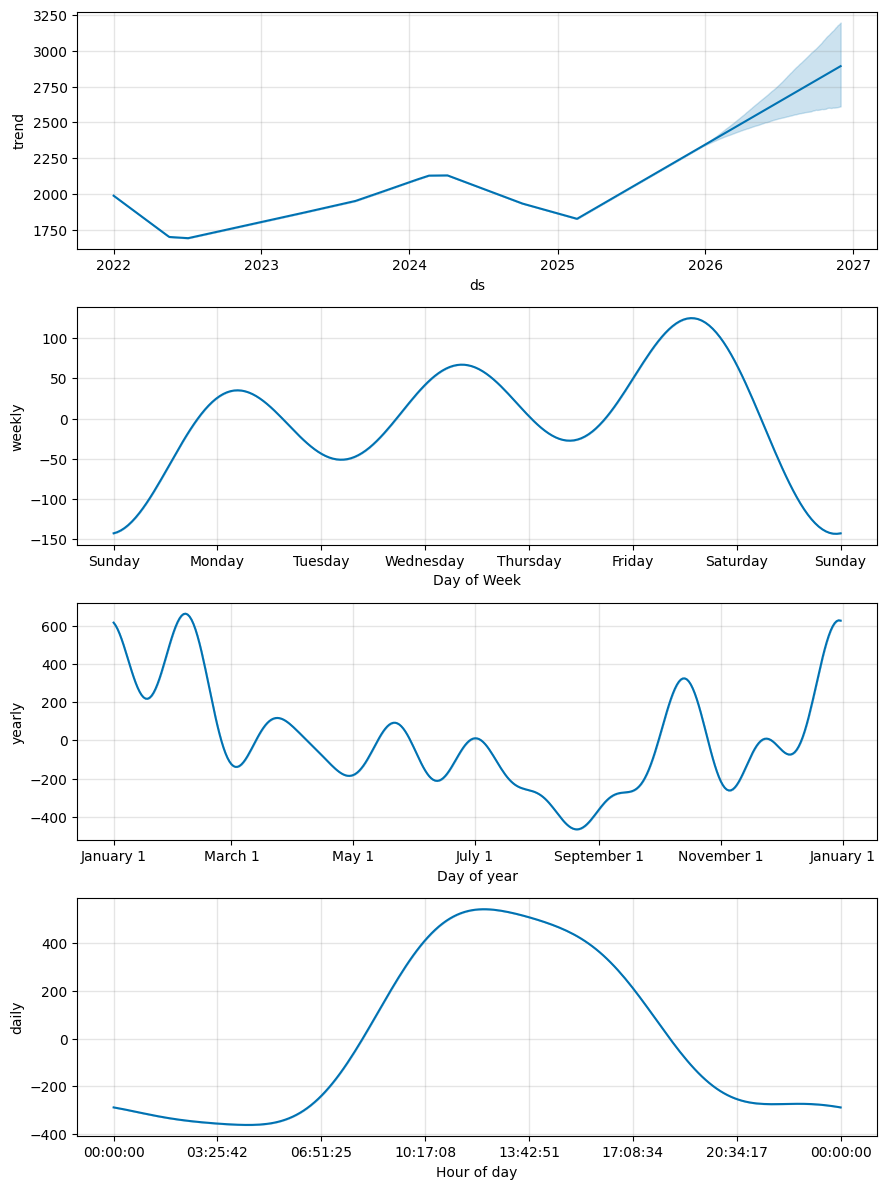

In [120]:
production_trend = predict_model_prophet(production_model, "production_trend")

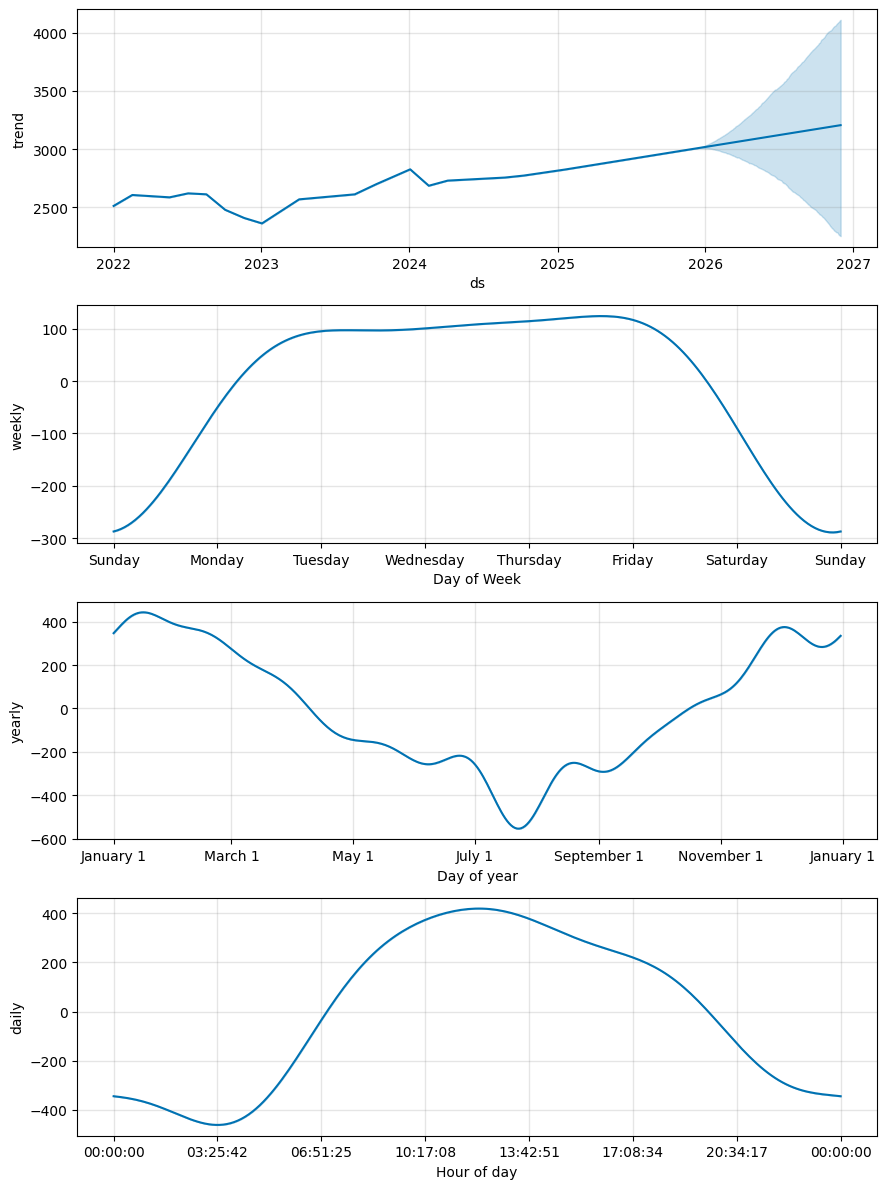

In [117]:
consumption_trend = predict_model_prophet(consumption_model, "consumption_trend")

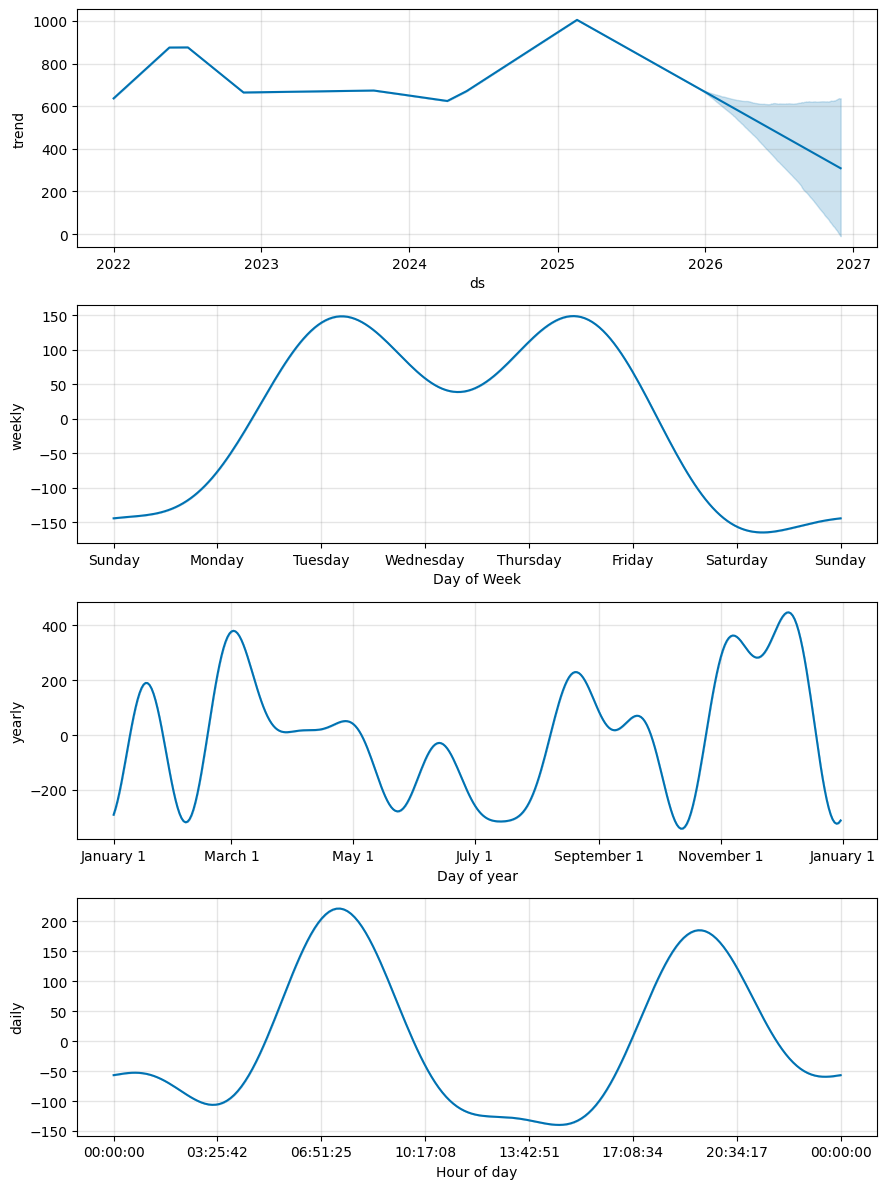

In [118]:
netload_trend = predict_model_prophet(netload_model, "netload_trend")

### 3. Forecast New projects on existing data

The current data from 2024-12-01 to 2025-11-30 is extended to 2026-11-30. The previous year data is used for production and consumption.
Once the data till 2026-11-30 is ready, distribute the new project loads by scaling over the year

In [144]:
def extend_data_for_a_year(data_df):
    data_df['ds'] = pd.to_datetime(data_df['ds'])

    # 2. Filter the data for the "previous year" period (2024-12-01 to 2025-11-30)
    # We use this as the template for the new year.
    start_date = '2024-12-01 00:00:00'
    end_date = '2025-11-30 23:00:00'
    mask = (data_df['ds'] >= start_date) & (data_df['ds'] <= end_date)
    previous_year_data = data_df.loc[mask].copy()

    # 3. Add exactly 1 year to the 'ds' column to move it to 2025/2026
    # pd.DateOffset(years=1) handles the calendar logic correctly
    data_df['ds'] = data_df['ds'] + pd.DateOffset(years=1)

    # 4. Append the new data to your original dataframe
    extended_df = pd.concat([data_df, previous_year_data], ignore_index=True)

    # Sort by date to ensure continuity
    extended_df = extended_df.sort_values('ds').reset_index(drop=True)
    return extended_df

In [172]:
production_df

,ds,y
0,2022-01-01 00:00:00,2057.425672
1,2022-01-01 01:00:00,2041.301143
2,2022-01-01 02:00:00,1941.723910
3,2022-01-01 03:00:00,1749.092176
4,2022-01-01 04:00:00,1590.741475
...,...,...
34311,2025-11-30 19:00:00,4631.274761
34312,2025-11-30 20:00:00,4688.119455
34313,2025-11-30 21:00:00,4725.786600
34314,2025-11-30 22:00:00,4702.579993


In [216]:
# Extend 2024-25 data to 2025-26 for production, consumption and net load
production_df_extended_nov26 = extend_data_for_a_year(production_df.tail(one_year_timeframe - 1).copy())
consumption_df_extended_nov26 = extend_data_for_a_year(consumption_df.tail(one_year_timeframe - 1).copy())
netload_df_extended_nov26 = extend_data_for_a_year(netload_df.tail(one_year_timeframe - 1).copy())

In [225]:
def add_additional_load(load_data):
    """
    Function to distribute a scalar value over a distribution.
    Find the scaling factor
        scaling_factor = new_load/total_load
        y_new = y + y*scaling_factor
    """
    load_data = production_df_extended_nov26.tail(one_year_timeframe - 1).copy()
    load_data["y"] = load_data["y"].clip(lower=0)
    total_load_per_yer = load_data["y"].sum()
    scaling_factor = NEW_PROJECT_PRODUCTION_PER_YEAR/total_load_per_yer
    load_distribution = load_data["y"] * scaling_factor

    load_data["y_newload"] = load_data["y"] + load_distribution
    return load_data

                       ds            y    y_newload
8759  2025-12-01 00:00:00  1965.045880  2111.046920
8760  2025-12-01 01:00:00  1838.139158  1974.711150
8761  2025-12-01 02:00:00  1685.063744  1810.262378
8762  2025-12-01 03:00:00  1670.683097  1794.813263
8763  2025-12-01 04:00:00  1687.713546  1813.109058
...                   ...          ...          ...
17513 2026-11-30 19:00:00  4631.274761  4975.374072
17514 2026-11-30 20:00:00  4688.119455  5036.442273
17515 2026-11-30 21:00:00  4725.786600  5076.908051
17516 2026-11-30 22:00:00  4702.579993  5051.977215
17517 2026-11-30 23:00:00  4590.548662  4931.622063

[8759 rows x 3 columns]


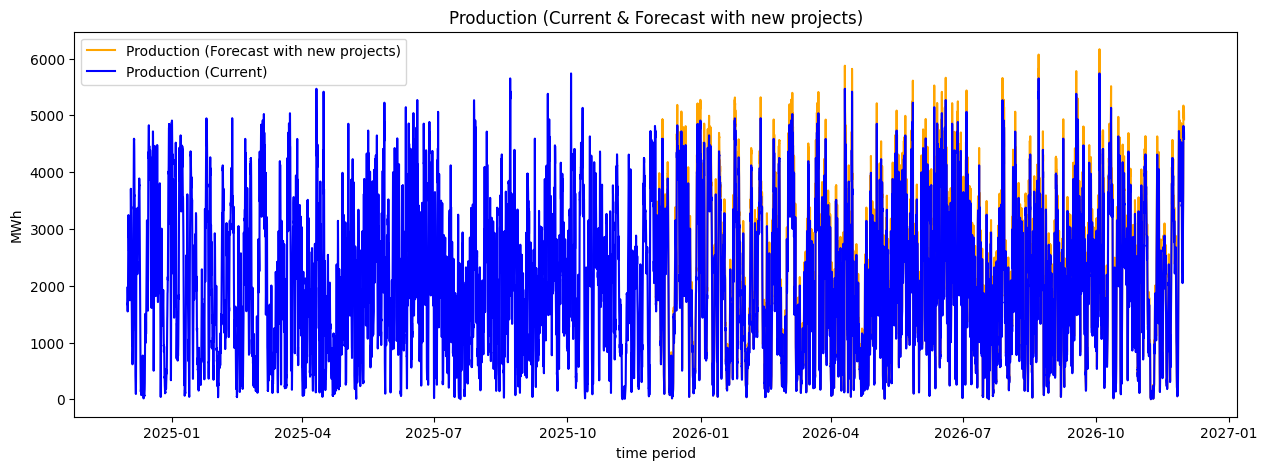

In [235]:
production2026_new_df = add_additional_load(production_df_extended_nov26)
print(production2026_new_df)

plt.figure(figsize=(15, 5))
plt.plot(production2026_new_df["ds"], production2026_new_df["y_newload"], label="Production (Forecast with new projects)", color="orange")
plt.plot(production_df_extended_nov26["ds"], production_df_extended_nov26["y"], label="Production (Current)", color="blue")
plt.xlabel("time period")
plt.ylabel("MWh")
plt.title("Production (Current & Forecast with new projects)")
plt.legend()
plt.savefig("graphs\\Production_current_forecast_4_3_2.png")
plt.show()

In [233]:
# Create a new production dataframe with ds and additional_production_data
d1 = production_df.tail(one_year_timeframe - 1).copy()
d2 = production2026_new_df.copy()[["ds", "y_newload"]]
production_2024_26_after_new = pd.concat([d1, d2.rename(columns={"y_newload": 'y'})], ignore_index=True)

In [234]:
net_load_after_new_2024_2026["ds"] = production_df_extended_nov26["ds"]
net_load_after_new_2024_2026 = consumption_extended_df["y"] - production_2024_26_after_new["y"]
net_load_before_new_2024_2026 = consumption_extended_df["y"] - production_2024_26_before_new["y"]

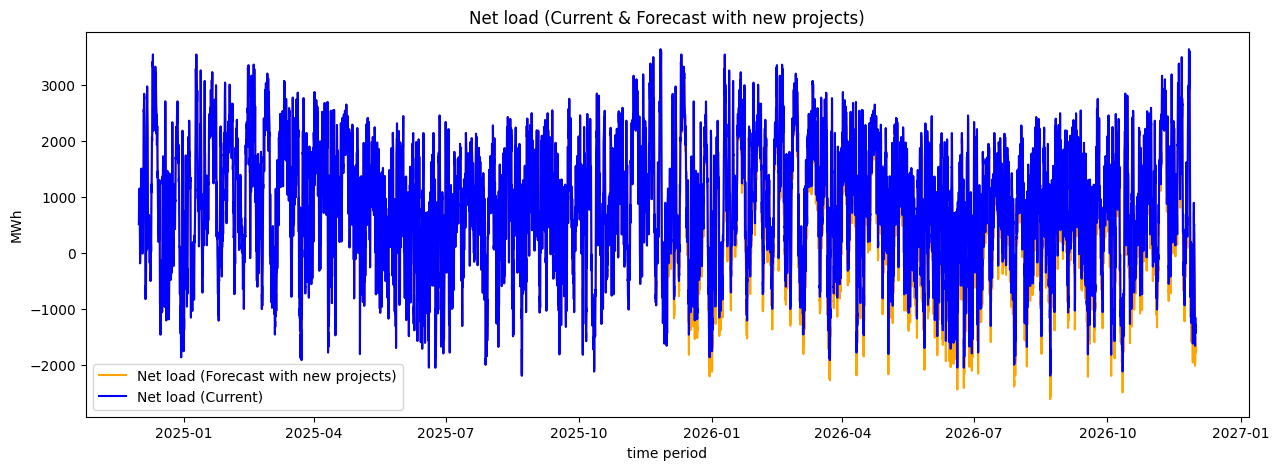

In [236]:
plt.figure(figsize=(15, 5))
plt.plot(production_2024_26_before_new["ds"], net_load_after_new_2024_2026, label="Net load (Forecast with new projects)", color="orange")
plt.plot(production_2024_26_after_new["ds"], net_load_before_new_2024_2026, label="Net load (Current)", color="blue")
plt.xlabel("time period")
plt.ylabel("MWh")
plt.title("Net load (Current & Forecast with new projects)")
plt.legend()
plt.savefig("graphs\\Netload_current_forecast_4_3_2.png")
plt.show()

In [252]:
netload_df_extend_nov26 = pd.concat([production_df_extended_nov26["ds"], net_load_before_new_2024_2026], axis=1)
netload_df_extend_nov26["y_new"] = net_load_after_new_2024_2026

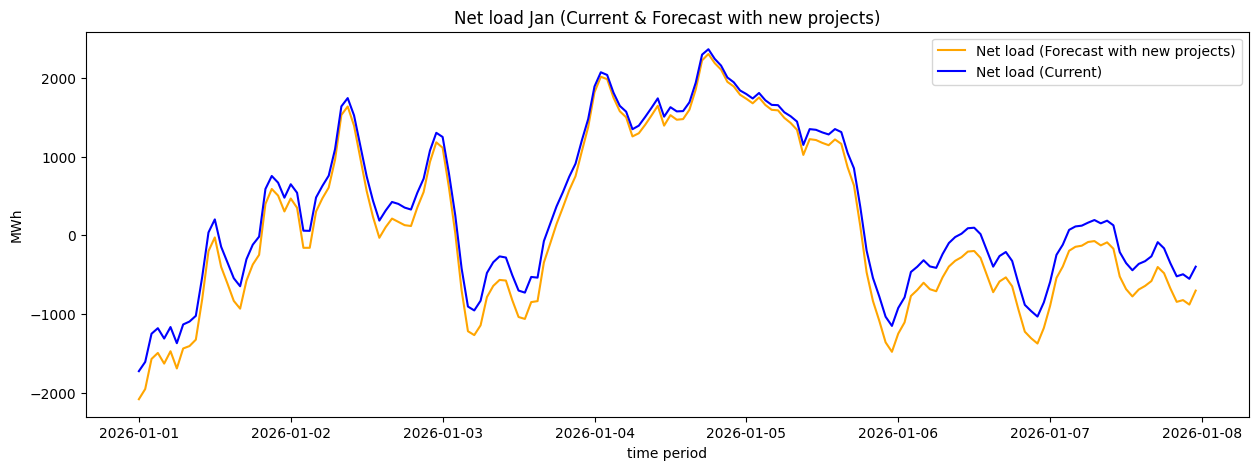

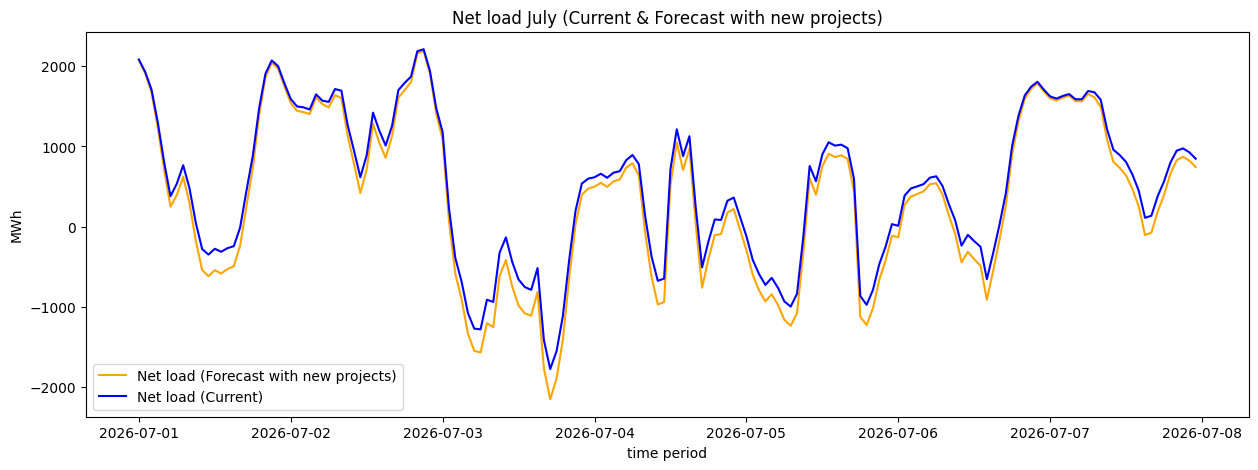

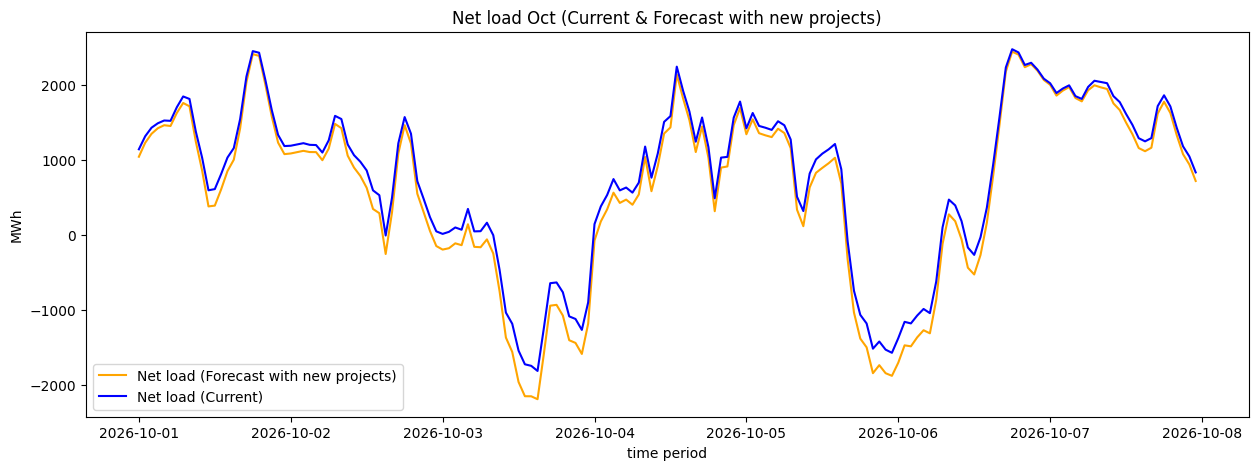

In [261]:
netload_df_short_jan26 = netload_df_extend_nov26[(netload_df_extend_nov26["ds"] >= "2026-01-01") & (netload_df_extend_nov26["ds"] < "2026-01-08")]
netload_df_short_july26 = netload_df_extend_nov26[(netload_df_extend_nov26["ds"] >= "2026-07-01") & (netload_df_extend_nov26["ds"] < "2026-07-08")]
netload_df_short_oct26 = netload_df_extend_nov26[(netload_df_extend_nov26["ds"] >= "2026-10-01") & (netload_df_extend_nov26["ds"] < "2026-10-08")]

def plot_week_data(netload_df, month):
    plt.figure(figsize=(15, 5))
    plt.plot(netload_df["ds"], netload_df["y_new"], label="Net load (Forecast with new projects)", color="orange")
    plt.plot(netload_df["ds"], netload_df["y"], label="Net load (Current)", color="blue")
    plt.xlabel("time period")
    plt.ylabel("MWh")
    plt.title(f"Net load {month} (Current & Forecast with new projects)")
    plt.legend()
    plt.savefig(f"graphs\\seasonal_sample_{month}_forecast_4_4.png")
    plt.show()

plot_week_data(netload_df_short_jan26, "Jan")
plot_week_data(netload_df_short_july26, "July")
plot_week_data(netload_df_short_oct26, "Oct")

In [257]:
netload_df_short_jan26

,ds,y,y_new
9503,2026-01-01 00:00:00,-1725.657061,-2081.832623
9504,2026-01-01 01:00:00,-1608.389954,-1952.607253
9505,2026-01-01 02:00:00,-1250.314708,-1570.425298
9506,2026-01-01 03:00:00,-1179.977370,-1494.025678
9507,2026-01-01 04:00:00,-1311.462562,-1629.471280
9508,2026-01-01 05:00:00,-1165.341567,-1472.764171
9509,2026-01-01 06:00:00,-1370.425161,-1691.211811
9510,2026-01-01 07:00:00,-1132.484226,-1437.407898
9511,2026-01-01 08:00:00,-1095.683149,-1406.932087
9512,2026-01-01 09:00:00,-1023.161071,-1325.577092
